# Exact GP Regression — the Three Patterns

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/exact_gp_regression.ipynb)

pyrox supports three modeling patterns for attaching priors to kernel hyperparameters. This notebook walks through all three using the **collapsed Gaussian-likelihood** path — same dataset, same SVI setup, same posterior — so the only thing that differs is how the priors are plumbed into the kernel.

**What you'll learn:**

1. The fixed-hyperparameter `GPPrior` / `ConditionedGP` mechanics.
2. Three ways to attach priors to an RBF kernel — pure Equinox, `PyroxModule`, and `Parameterized`.
3. Fitting kernel hyperparameters with SVI via `gp_factor`.

## Background

### GP prior and likelihood

A Gaussian process prior with zero mean and covariance function
$k_\theta$ places a joint Gaussian over any finite collection of
function values: for inputs $X = \{x_i\}_{i=1}^N$,

$$p(f \mid X, \theta) = \mathcal{N}\!\bigl(f \mid 0, K_{XX}\bigr),
\qquad (K_{XX})_{ij} = k_\theta(x_i, x_j).$$

With Gaussian observations $y_i = f(x_i) + \varepsilon_i$ and
$\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, the **marginal**
likelihood is obtained by integrating out $f$,

$$p(y \mid X, \theta, \sigma^2)
= \int p(y \mid f, \sigma^2)\, p(f \mid X, \theta)\, df = \mathcal{N}\!\bigl(y \mid 0, K_{XX} + \sigma^2 I\bigr).$$

Taking logs gives the **collapsed log marginal likelihood** that every GP regression workflow optimizes or samples:

$$\log p(y \mid X, \theta, \sigma^2)
= -\tfrac{1}{2} y^\top (K_{XX} + \sigma^2 I)^{-1} y -\tfrac{1}{2}\log\bigl|K_{XX} + \sigma^2 I\bigr| -\tfrac{N}{2}\log(2\pi).$$

pyrox exposes this as `gp_factor("obs", prior, y, noise_var)`, which delegates to `gaussx.log_marginal_likelihood` under the hood and drops into any NumPyro model.

### Posterior predictive

Given training observations $(X, y)$ and test inputs $X_*$, the GP posterior at $X_*$ is Gaussian with closed-form moments:

$$\mu_* = K_{*X}\bigl(K_{XX} + \sigma^2 I\bigr)^{-1} y,$$

$$\Sigma_* = K_{**} - K_{*X}\bigl(K_{XX} + \sigma^2 I\bigr)^{-1} K_{X*}.$$

`GPPrior.condition(y, noise_var).predict(X_star)` returns the diagonal of $\Sigma_*$ via `gaussx.predict_mean` and `gaussx.predict_variance`.

### Kernel and hyperparameter priors

This notebook uses the squared-exponential (RBF) kernel,

$$k_\theta(x, x') = \sigma_f^2 \exp\!\Bigl(-\tfrac{\|x - x'\|^2}{2\ell^2}\Bigr),
\qquad \theta = (\sigma_f^2, \ell),$$

with log-normal priors on both hyperparameters,
$\sigma_f^2, \ell \sim \mathrm{LogNormal}(0, 1)$. Log-normal keeps
the samples positive without the explicit `dist.constraints.positive` bookkeeping that `Parameterized` handles automatically for pattern C.

### The three patterns

| Pattern | Where hyperparameters live | When to reach for it |
|---|---|---|
| **A** | Pure `eqx.Module`, sampled in the NumPyro model, spliced with `eqx.tree_at` | Lightweight; drop a Bayesian layer into existing Equinox code. |
| **B** | Custom `PyroxModule` kernel, sampled inside `__call__` via `pyrox_sample` | Self-contained probabilistic kernel; no model-side plumbing. |
| **C** | `Parameterized` kernel (pyrox ships `RBF`, `Matern`, etc.); `set_prior` / `autoguide` / `set_mode` | Rich registry with constraints, priors, and mode switching. |

All three fit the same data to the same posterior — the choice is ergonomics.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there. Local / CI users with the environment already set up skip the install and go straight to the imports.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jaxtyping import Array, Float
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

from pyrox._core import PyroxModule, pyrox_method
from pyrox.gp import RBF, GPPrior, Kernel, gp_factor
from pyrox.gp._src.kernels import rbf_kernel


jax.config.update("jax_enable_x64", True)

Print an explicit version / platform readout so reproducing this notebook later is unambiguous.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,gaussx,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
gaussx    : 0.0.10
pyrox     : 0.0.2
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Toy dataset

A noisy sine curve with a gap — the gap is where the posterior uncertainty band should visibly widen for any well-fit GP.

In [4]:
key = jr.PRNGKey(0)

f_true = lambda x: jnp.sin(2.0 * x) + 0.3 * jnp.cos(5.0 * x)

X_train = jnp.concatenate(
    [jnp.linspace(-3.0, -0.5, 10), jnp.linspace(1.5, 3.0, 10)]
).reshape(-1, 1)
noise_std = 0.15
y_train = f_true(X_train.squeeze(-1)) + noise_std * jr.normal(key, (X_train.shape[0],))
X_test = jnp.linspace(-3.5, 3.5, 200).reshape(-1, 1)
noise_var = jnp.array(noise_std**2)

print(f"Training points: {X_train.shape[0]}")
print(f"Test points:     {X_test.shape[0]}")

Training points: 20
Test points:     200


## Fixed-hyperparameter baseline

Before looking at priors, it's useful to see the raw mechanics of the `GPPrior` / `ConditionedGP` path. Instantiate an RBF with default hyperparameters, condition on the observations, predict on a dense grid. `GPPrior.solver` defaults to `gaussx.DenseSolver()`; swap for any other `gaussx.AbstractSolverStrategy` at construction time.

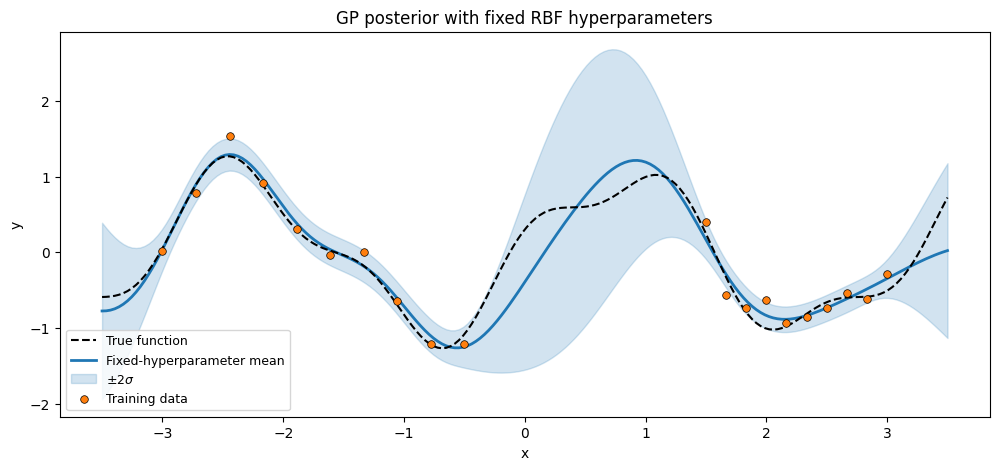

In [5]:
kernel_fixed = RBF(init_variance=1.0, init_lengthscale=0.6)
prior_fixed = GPPrior(kernel=kernel_fixed, X=X_train)

with numpyro.handlers.seed(rng_seed=0):
    cond_fixed = prior_fixed.condition(y_train, noise_var)
    mean_fixed, var_fixed = cond_fixed.predict(X_test)
std_fixed = jnp.sqrt(jnp.clip(var_fixed, min=0.0))


def plot_posterior(ax, mean, std, label):
    ax.plot(
        X_test.squeeze(),
        f_true(X_test.squeeze()),
        "k--",
        lw=1.5,
        label="True function",
        zorder=4,
    )
    ax.plot(X_test.squeeze(), mean, "C0-", lw=2, label=f"{label} mean", zorder=3)
    ax.fill_between(
        X_test.squeeze(),
        mean - 2 * std,
        mean + 2 * std,
        color="C0",
        alpha=0.2,
        label=r"$\pm 2\sigma$",
    )
    ax.scatter(
        X_train.squeeze(),
        y_train,
        s=30,
        c="C1",
        edgecolors="k",
        linewidths=0.5,
        label="Training data",
        zorder=5,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="lower left", fontsize=9)


fig, ax = plt.subplots(figsize=(12, 5))
plot_posterior(ax, mean_fixed, std_fixed, "Fixed-hyperparameter")
ax.set_title("GP posterior with fixed RBF hyperparameters")
plt.show()

Now we turn the RBF's `variance` and `lengthscale` into random variables with $\mathrm{LogNormal}(0, 1)$ priors, and fit them with SVI. The three patterns differ only in *how* the priors are attached to the kernel — the NumPyro model, SVI loop, and final posterior are the same.

## Fitting hyperparameters with SVI

Stochastic variational inference maximizes the ELBO

$$\mathcal{L}(q) = \mathbb{E}_{q(\theta)}\bigl[\log p(y, \theta)\bigr]
- \mathbb{E}_{q(\theta)}\bigl[\log q(\theta)\bigr] = \mathbb{E}_{q(\theta)}\bigl[\log p(y \mid \theta)\bigr]
- \mathrm{KL}\!\bigl(q(\theta) \,\|\, p(\theta)\bigr),$$

where $q(\theta)$ is the variational family — here `AutoNormal` which places a mean-field Gaussian on each transformed hyperparameter. The three patterns differ only in *how* the prior
$p(\theta)$ is attached to the kernel.

## Pattern A — pure Equinox + `eqx.tree_at`

Write a minimal `Kernel` subclass with `variance` and `lengthscale` as plain `eqx.Module` fields. Sample the hyperparameters inside the NumPyro model and splice them into the kernel with `eqx.tree_at`.

$$\theta \sim p(\theta) \;\Rightarrow\; k = \text{tree\_at}(k_0, \theta)
\;\Rightarrow\; \log p(y \mid X, \theta) \text{ via gp\_factor}.$$

Use this when you already have Equinox-native modules and want to add priors without subclassing any pyrox machinery.

In [6]:
class RBFLite(Kernel):
    """Minimal Equinox-native RBF kernel."""

    variance: Float[Array, ""]
    lengthscale: Float[Array, ""]

    def __call__(
        self, X1: Float[Array, "N1 D"], X2: Float[Array, "N2 D"]
    ) -> Float[Array, "N1 N2"]:
        return rbf_kernel(X1, X2, self.variance, self.lengthscale)


def model_pattern_a(X, y, noise_var):
    variance = numpyro.sample("variance", dist.LogNormal(0.0, 1.0))
    lengthscale = numpyro.sample("lengthscale", dist.LogNormal(0.0, 1.0))
    kernel = RBFLite(variance=jnp.array(1.0), lengthscale=jnp.array(1.0))
    kernel = eqx.tree_at(
        lambda k: (k.variance, k.lengthscale),
        kernel,
        (variance, lengthscale),
    )
    prior = GPPrior(kernel=kernel, X=X)
    gp_factor("obs", prior, y, noise_var)

## Pattern B — `PyroxModule` kernel with `pyrox_sample`

Subclass `PyroxModule` (and `Kernel` for the protocol) and register the hyperparameters as sample sites *inside* `__call__` via `self.pyrox_sample`. The `pyrox_method` decorator activates the per-call cache so every `kernel(X1, X2)` invocation sees the same hyperparameter draw:

$$k(x, x') = \sigma_f^2 \exp\!\bigl(-\|x-x'\|^2 / 2\ell^2\bigr),
\quad \sigma_f^2, \ell \sim p(\theta) \text{ on first call}.$$

The kernel now owns its probabilistic semantics — the NumPyro model doesn't need to plumb anything.

In [7]:
class RBFPyrox(Kernel, PyroxModule):
    """PyroxModule kernel with inline prior registration."""

    pyrox_name: str = "RBFPyrox"

    @pyrox_method
    def __call__(
        self, X1: Float[Array, "N1 D"], X2: Float[Array, "N2 D"]
    ) -> Float[Array, "N1 N2"]:
        variance = self.pyrox_sample("variance", dist.LogNormal(0.0, 1.0))
        lengthscale = self.pyrox_sample("lengthscale", dist.LogNormal(0.0, 1.0))
        return rbf_kernel(X1, X2, variance, lengthscale)


def model_pattern_b(X, y, noise_var):
    kernel = RBFPyrox()
    prior = GPPrior(kernel=kernel, X=X)
    gp_factor("obs", prior, y, noise_var)

## Pattern C — `Parameterized` kernel with `set_prior`

Use the shipped `pyrox.gp.RBF` class and call `set_prior` once per hyperparameter. `Parameterized` owns the registry: priors, guides (`autoguide`), constraints, and mode switching all live here.

Because `variance` and `lengthscale` were registered with the positivity constraint on the `Parameterized` side, the
$\mathrm{LogNormal}(0, 1)$ prior composes cleanly through a
`TransformedDistribution`,

$$q(\theta) = \mathrm{biject}\bigl(\mathcal{N}\!\bigl(\mu_\theta, \mathrm{diag}(\sigma_\theta^2)\bigr)\bigr),$$

so every SVI draw is guaranteed to land in the prior's support.

This is the richest of the three patterns — reach for it when you want the full priors / autoguide / mode story without hand-rolling it.

In [8]:
def model_pattern_c(X, y, noise_var):
    kernel = RBF()
    kernel.set_prior("variance", dist.LogNormal(0.0, 1.0))
    kernel.set_prior("lengthscale", dist.LogNormal(0.0, 1.0))
    prior = GPPrior(kernel=kernel, X=X)
    gp_factor("obs", prior, y, noise_var)

## Fit all three with the same SVI loop

In [9]:
def fit(model_fn, seed, n_steps=400):
    guide = AutoNormal(model_fn)
    svi = SVI(model_fn, guide, Adam(5e-2), Trace_ELBO())
    state = svi.init(jr.PRNGKey(seed), X_train, y_train, noise_var)
    losses = []
    for _ in range(n_steps):
        state, loss = svi.update(state, X_train, y_train, noise_var)
        losses.append(float(loss))
    return state, svi, losses


state_a, svi_a, losses_a = fit(model_pattern_a, 1)
state_b, svi_b, losses_b = fit(model_pattern_b, 2)
state_c, svi_c, losses_c = fit(model_pattern_c, 3)


def posterior_hyperparams(svi, state, variance_site, lengthscale_site):
    params = svi.get_params(state)
    variance = float(jnp.exp(params[f"{variance_site}_auto_loc"]))
    lengthscale = float(jnp.exp(params[f"{lengthscale_site}_auto_loc"]))
    return variance, lengthscale


v_a, ls_a = posterior_hyperparams(svi_a, state_a, "variance", "lengthscale")
v_b, ls_b = posterior_hyperparams(
    svi_b, state_b, "RBFPyrox.variance", "RBFPyrox.lengthscale"
)
v_c, ls_c = posterior_hyperparams(svi_c, state_c, "RBF.variance", "RBF.lengthscale")

print(f"{'pattern':<10} {'variance':>10} {'lengthscale':>12}")
print("-" * 36)
print(f"{'A':<10} {v_a:>10.3f} {ls_a:>12.3f}")
print(f"{'B':<10} {v_b:>10.3f} {ls_b:>12.3f}")
print(f"{'C':<10} {v_c:>10.3f} {ls_c:>12.3f}")

pattern      variance  lengthscale
------------------------------------
A               0.825        0.439
B               0.617        0.451
C               0.792        0.429


The three fitted posteriors should agree up to stochastic SVI noise — a good sanity check that the patterns are semantically equivalent.

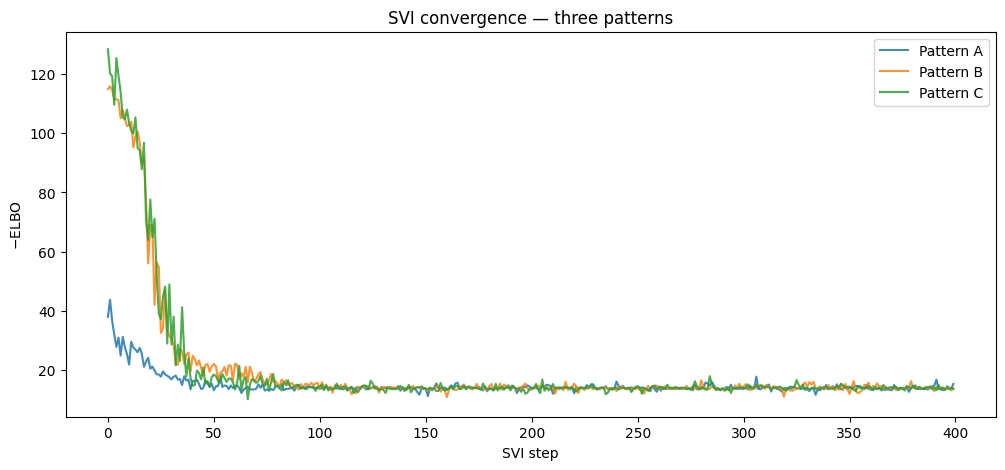

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses_a, "C0-", label="Pattern A", alpha=0.85)
ax.plot(losses_b, "C1-", label="Pattern B", alpha=0.85)
ax.plot(losses_c, "C2-", label="Pattern C", alpha=0.85)
ax.set_xlabel("SVI step")
ax.set_ylabel(r"$-$ELBO")
ax.set_title("SVI convergence — three patterns")
ax.legend()
plt.show()

Rebuild each kernel at the fitted posterior mean and predict on the dense grid. Overlaying the three posterior means makes it easy to confirm they agree.

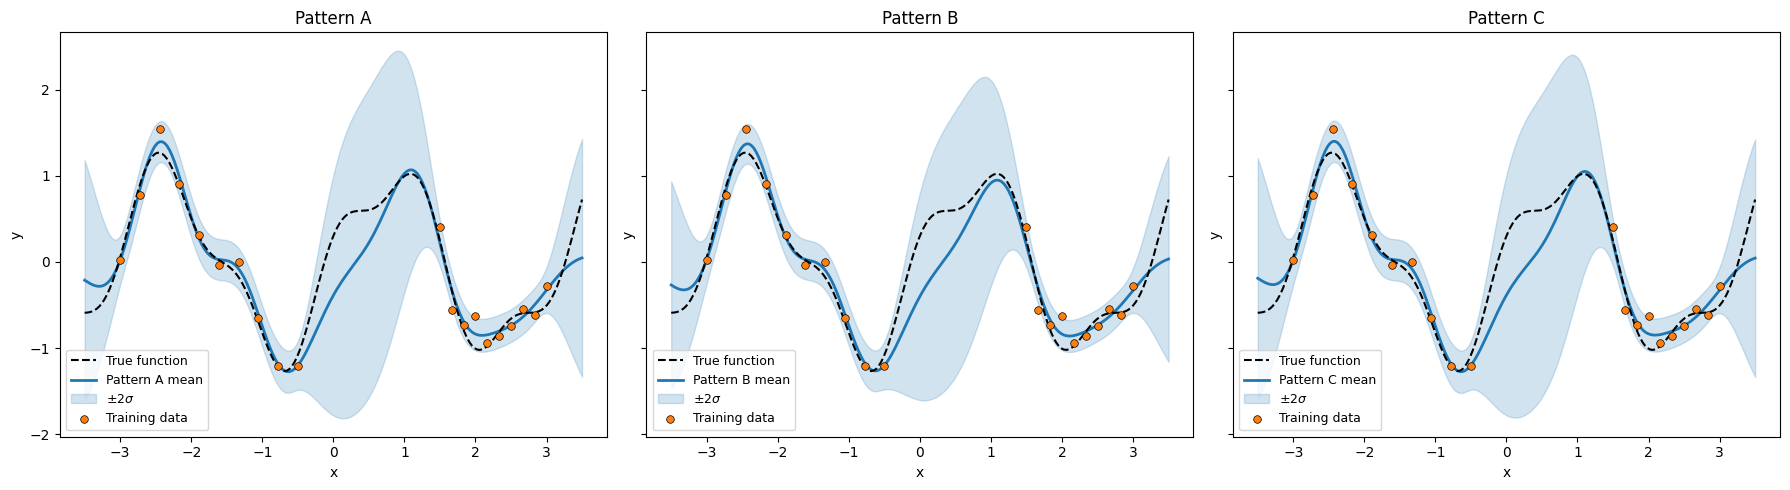

In [11]:
def predict_with(variance, lengthscale):
    kernel = RBF(init_variance=variance, init_lengthscale=lengthscale)
    prior = GPPrior(kernel=kernel, X=X_train)
    with numpyro.handlers.seed(rng_seed=0):
        cond = prior.condition(y_train, noise_var)
        mean, var = cond.predict(X_test)
    return mean, jnp.sqrt(jnp.clip(var, min=0.0))


mean_a, std_a = predict_with(v_a, ls_a)
mean_b, std_b = predict_with(v_b, ls_b)
mean_c, std_c = predict_with(v_c, ls_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, mean, std, title in zip(
    axes,
    [mean_a, mean_b, mean_c],
    [std_a, std_b, std_c],
    ["Pattern A", "Pattern B", "Pattern C"],
):
    plot_posterior(ax, mean, std, title)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## When to use which

- **Pattern A** — lightest touch. Good when the rest of your code is already pure Equinox and you want to sprinkle a single Bayesian layer on top. No pyrox base classes needed.
- **Pattern B** — the kernel is probabilistic by construction. Good when you ship a reusable kernel and want the priors to travel with it. Pick this when the kernel is genuinely "one thing" that happens to have randomness.
- **Pattern C** — full registry. Best when you want constraints, autoguides, mode switching, and the rich `set_prior` / `autoguide` / `set_mode` API. The shipped `RBF`, `Matern`, `Periodic`, etc. use this pattern; subclass `Parameterized` for your own.

All three compose with NumPyro handlers, MCMC, SVI, and JAX transforms identically — the choice is purely ergonomic.